# Оценка нового алгоритма рекомендаций в развлекательном приложении: A/B-тест метрики вовлеченности пользователей.

## Описание данных

Мы будем работать с тремя таблицами:

- `sessions_project_history.csv` - таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` - таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` - таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` - идентификатор пользователя;

- `session_id` - идентификатор сессии в приложении;

- `session_date` - дата сессии;

- `session_start_ts` - дата и время начала сессии;

- `install_date` - дата установки приложения;

- `session_number` - порядковый номер сессии для конкретного пользователя;

- `registration_flag` - является ли пользователь зарегистрированным;

- `page_counter` - количество просмотренных страниц во время сессии;

- `region` - регион пользователя;

- `device` - тип устройства пользователя;

- `test_group` - тестовая группа (в таблице с историческими данными этого столбца нет).


## Задачи исследования
Основные задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

**Особенности А/В теста:**
- **Гипотеза:** новый алгоритм рекомендаций, будет показывать более интересный контент для каждого пользователя и тем самым повысит вовлечённость пользователей приложения.
- **Целевая метрика:** в данному случае целевой метрикой будет являться доля сессий с просмотром 4 и более страниц (good_session = 1). Этот показатель должен отражать, насколько контент, предлагаемый новым алгоритмом, захватывает пользователя. Если алгоритм действительно лучше подбирает материалы, люди должны чаще задерживаться в приложении и листать дальше страницы.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных

Импортируем основные библитеки.

In [1]:
import pandas as pd # Импортируем библиотеку pandas

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

from math import ceil

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest

Сохраним в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

In [2]:
# Выгружаем данные в переменную sessions_history
sessions_history = pd.read_csv('sessions_project_history.csv')

Выведем на экран первые пять строк полученного датафрейма.

In [3]:
sessions_history.head(5) # Выводим на экран первые пять строк полученного датафрейма

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными

Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

In [32]:
# Для каждого уникального пользователя рассчитаем количество уникальных сессий
sessions_per_user = sessions_history.groupby('user_id')['session_id'].nunique().reset_index(name='session_count').sort_values(ascending=False, by='session_count')

# Проверим результат
sessions_per_user.head()

,user_id,session_count
8948,10E0DEFC1ABDBBE0,10
55627,6A73CB5566BB494D,10
109383,D11541BAC141FB94,9
121862,E8ADFF2913E86056,9
131181,FA752AB58040C361,9


Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий.

In [33]:
# Выбираем пользователя с наибольшим количеством сессий
top_user = sessions_per_user.iloc[0]['user_id']

# Выводим все данные пользователя с наибольшим количеством сессий
display(sessions_history[sessions_history['user_id'] == top_user])

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,good_session
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android,1
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android,0
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android,0
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android,0
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android,1
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android,0
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android,0
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android,0
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android,0
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android,0


**Промежуточный вывод:**
- Пользователь с user_id: 10E0DEFC1ABDBBE0 имеет наибольшее количество сессий, также про него известно следующее:
    - Данный пользователь заходил в приложение в период с 14 августа 2025г. по 25 августа 2025г.
    - Указанный пользователь несмотря на свою активность не является зарегистрированным
    - Пользователь при просмотре приложения использует устройство Android
    - Регион пользователя - CIS

**Вывод:** пользователь демонстрирует интерес к приложению, но не достигает регистрации. Это может свидетельствовать о том, что контент удерживает его, но отсутствует триггер для его регистрации в приложении.

#### 1.3. Анализ числа регистраций

Одна из важнейших метрик продукта - число зарегистрированных пользователей. Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

В начале агрегируем исторические данные и рассчитаем число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты посчитаем, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

In [6]:
# считаем общее количество пользователей и количество зарегистрированных пользователей
registered_users_count = sessions_history.groupby('session_date').agg(
    total_users=('user_id', 'nunique'),
    registered_users=('registration_flag', 'sum')).reset_index()

# выводим первые строки полученных данных
registered_users_count.head()

,session_date,total_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840


Посчитаем доли зарегистрированных пользователей от всех пользователей

In [7]:
# считаем долю зарегистрированных пользователей от общего числа пользователей
registered_users_count['share_registered_users'] = registered_users_count['registered_users']/registered_users_count['total_users']

# Выводим полученные данные
registered_users_count.head()

,session_date,total_users,registered_users,share_registered_users
0,2025-08-11,3919,169,0.043123
1,2025-08-12,6056,336,0.055482
2,2025-08-13,8489,464,0.054659
3,2025-08-14,10321,625,0.060556
4,2025-08-15,14065,840,0.059723


Построим линейный график общего числа пользователей и общего числа зарегистрированных пользователей по дням.

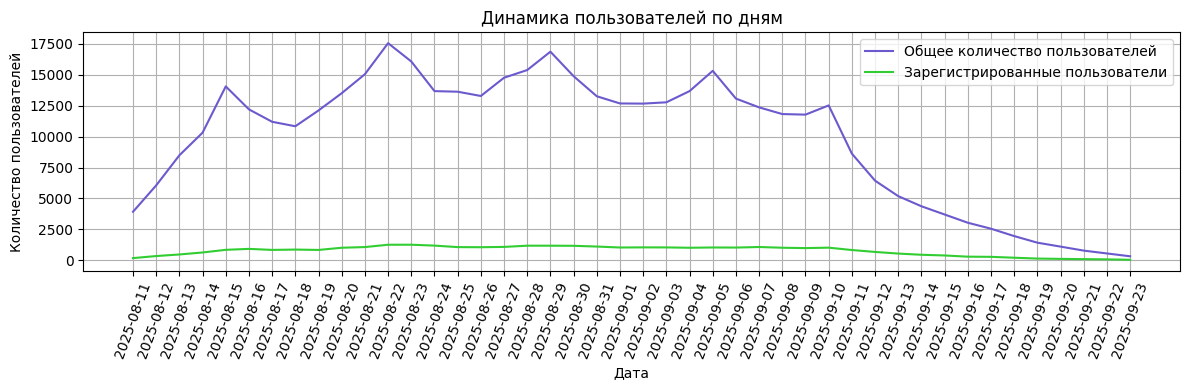

In [8]:
#создаем фигуру и оси с нужным размером
fig, ax = plt.subplots(figsize=(12, 4))

# Строим линейный график для визуализации данных
ax.plot(registered_users_count['session_date'], registered_users_count['total_users'], color='slateblue')
ax.plot(registered_users_count['session_date'], registered_users_count['registered_users'], color='limegreen')

# Устанавливаем подписи для заголовка, осей x и y
ax.set_title('Динамика пользователей по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Количество пользователей')

ax.grid(True)

ax.legend(['Общее количество пользователей', 'Зарегистрированные пользователи'], loc='upper right')
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

Построим линейный график доли зарегистрированных пользователей от всех пользователей по дням.

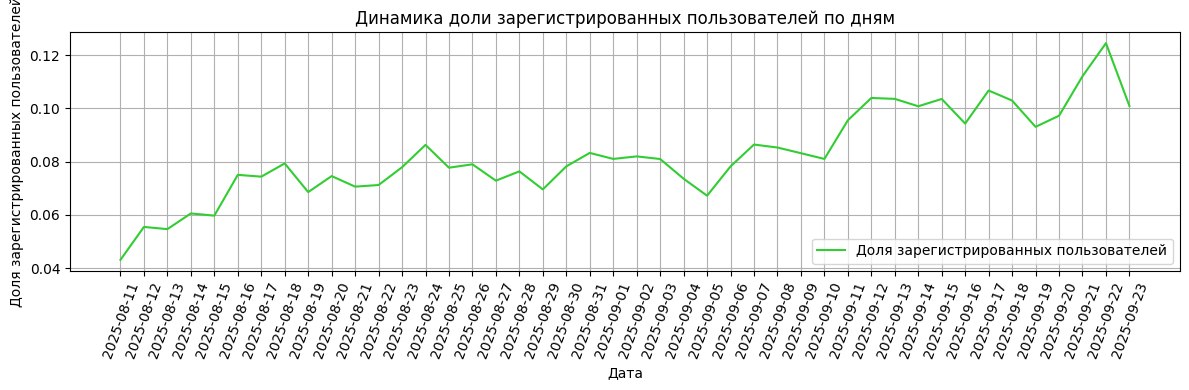

In [9]:
#создаем фигуру и оси с нужным размером
fig, ax = plt.subplots(figsize=(12, 4))

# Строим линейный график для визуализации данных
ax.plot(registered_users_count['session_date'], registered_users_count['share_registered_users'], color='limegreen')

# Устанавливаем подписи для заголовка, осей x и y
ax.set_title('Динамика доли зарегистрированных пользователей по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Доля зарегистрированных пользователей')

ax.grid(True)

ax.legend(['Доля зарегистрированных пользователей'], loc='lower right')
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Динамика аудитории: наблюдается рост общего числа активных пользователей с 3919 до 14065 за первые пять дней наблюдения (с 11 по 15 августа)
- Динамика регистраций: растет число зарегистрированных пользователей также растёт (с 169 до 840)
- Доля зарегистрированных пользователей: колеблется от 4.3-6.1%, что является низким показателем и может указывать на:
    - Недостаточную мотивацию пользователей к регистрации
    - Сложность интерфейса регистрации пользователей

**Вывод:** стоит обратить внимание на задачу увеличения количества регистраций пользователей. Возможно, стоит провести эксперименты по увеличению конверсии в регистрацию.

#### 1.4. Анализ числа просмотренных страниц

Другая важная метрика продукта - число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

Проанализируем число просмотренных страниц во время первых сессий пользователей. Найдём количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

In [10]:
# Отбираем первые сессии пользователей
first_sessions = sessions_history[sessions_history['session_number'] == 1]

# Считаем число просмотренных страниц во время первых сессий
page_views_counter = first_sessions.groupby('page_counter')['session_id'].count().reset_index()

print(page_views_counter)

   page_counter  session_id
0             1        8978
1             2       32494
2             3       50939
3             4       32739
4             5        8075
5             6         777
6             7          37


Построим столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

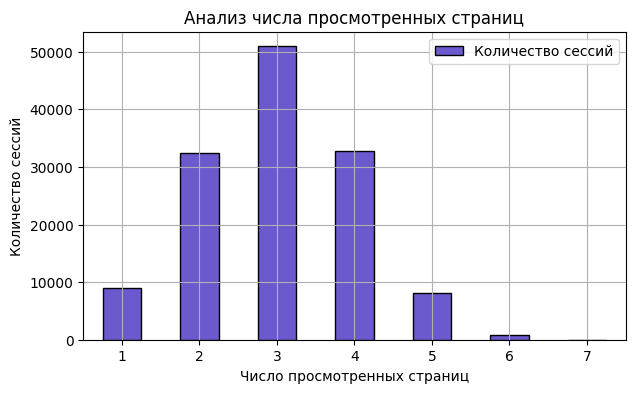

In [11]:
#создаем фигуру и оси с нужным размером
fig, ax = plt.subplots(figsize=(7, 4))

# создаем столбчатую диаграмму для визуализации данных
page_views_counter.plot(
    kind='bar',
    ax=ax,
    x='page_counter', 
    y='session_id',
    rot=0,
    color='slateblue',
    legend=False,
    edgecolor='black'
)

# Устанавливаем подписи для заголовка, осей x и y
ax.set_title('Анализ числа просмотренных страниц')
ax.set_xlabel('Число просмотренных страниц')
ax.set_ylabel('Количество сессий')

ax.legend(['Количество сессий'], loc='upper right')

ax.grid(True)

plt.show()

**Промежуточный вывод:**
- Пик просмотров приходится на 3 страницы во время одной сессии у пользователей
- В основном пользователи просматривают от 2 до 4 страниц во время первой сессии
- Немного пользователей останаливаются только на просмотре 1 страницы приложения, что говорит о том, что пользователям интересен контент приложения
- После 3 просмотренных страниц интерес пользователей начинает падать, особенно резкое падение начинается на 5 странице приложения

**Вывод:** стоит проанализировать 4 страницу приложения, т.е. почему пользователи перестают дальше просматривать страницы

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

По условию проекта сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

В датафрейме `sessions_history` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

In [12]:
# Создаём столбец good_session
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

In [13]:
# Оставляем только первые сессии
first_sessions = sessions_history[sessions_history['session_number'] == 1]

In [14]:
# Считаем общее число первых сессий и число успешных сессий
successful_sessions = first_sessions.groupby('session_date').agg(
    total_sessions=('good_session', 'count'), # количество первых сессий в день
    good_sessions=('good_session', 'sum') # количество успешных сессий в день
).reset_index()

In [15]:
# Считаем долю успешных сессий
successful_sessions['share_of_good_sessions'] = successful_sessions['good_sessions'] / successful_sessions['total_sessions']

successful_sessions.describe()

,total_sessions,good_sessions,share_of_good_sessions
count,31.000000,31.000000,31.000000
mean,4323.838710,1342.838710,0.310838
std,1404.271961,434.147601,0.006969
min,2364.000000,748.000000,0.297384
25%,3118.000000,985.000000,0.307642
50%,3988.000000,1226.000000,0.310680
75%,5205.500000,1622.500000,0.314538
max,7801.000000,2427.000000,0.331788


Построим график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные визуализируем по дням за весь период наблюдения.

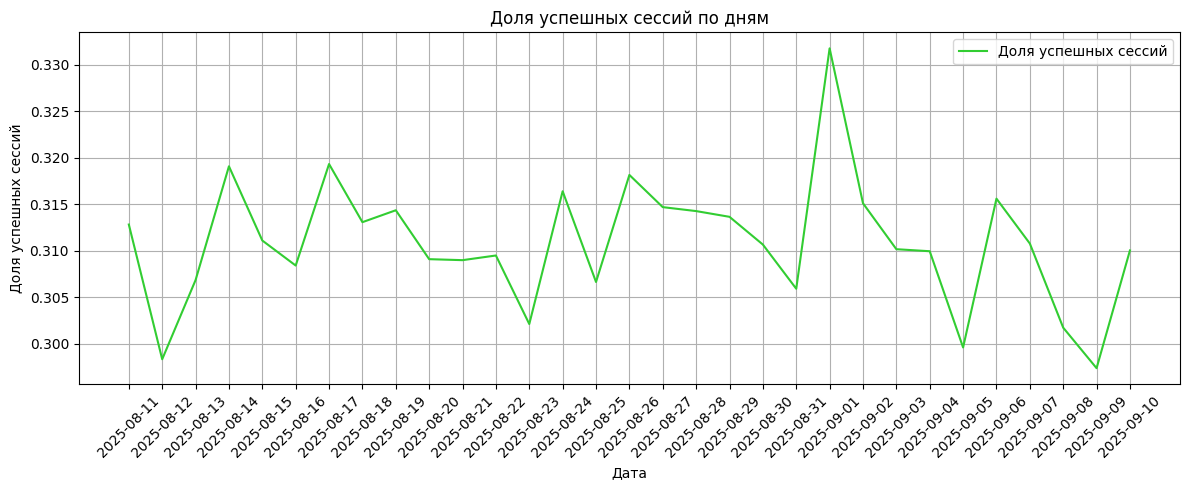

In [16]:
#создаем фигуру и оси с нужным размером
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(successful_sessions['session_date'], successful_sessions['share_of_good_sessions'], color='limegreen')

ax.set_title('Доля успешных сессий по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('Доля успешных сессий')

ax.legend(['Доля успешных сессий'], loc='upper right')

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

**Промежуточный вывод:**
- Доля успешных первых сессий (с просмотром более 4 страниц) колеблется в диапазоне с 29,7% – 33,2%
- График со средним значением доли успешных сессий от всех первых сессий пользователей не демонстрирует резких изменений в росте или падении

### 2. Подготовка к тесту

#### 2.1. Расчёт размера выборки

Установим в коде ниже следующие параметры:
- Уровень значимости — 0.05.
- Вероятность ошибки второго рода — 0.2.
- Мощность теста.
- Минимальный детектируемый эффект, или MDE, - 3%.

При расчёте размера выборки используем метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

In [17]:
# Задаём параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используя данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения, рассчитаем длительность теста, разделив одно на другое.

Для этого сделаем следующее:
- Рассчитаем среднее количество уникальных пользователей приложения в день.
- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [18]:
# Считаем среднее количество уникальных пользователей приложения в день
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean().round().astype(int)

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size / (avg_daily_users / 2))

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие нас метрики корректно считаются.

Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

In [19]:
# Выгружаем данные в переменную sessions_test_part
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

# Выводим первые строки полученного датафрейма
sessions_test_part.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B


Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

In [20]:
# Выбираем данные за первый день проведения A/B-теста, то есть за 2025-10-14
first_day = sessions_test_part[sessions_test_part['session_date']=='2025-10-14']

# Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп
test_group_count = first_day.groupby('test_group')['user_id'].nunique()

# Выведем результат
print(test_group_count)

test_group
A    1477
B    1466
Name: user_id, dtype: int64


Рассчитаем и выведем на экран процентную разницу в количестве пользователей в группах A и B.

Для расчёта процентной разницы воспользуемся формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

In [21]:
# Перепишем значения групп в переменные
group_a = test_group_count['A']
group_b = test_group_count['B']

# Считаем процентную разницу групп
percent_diff = ((group_a - group_b)/group_a) * 100

# Выводим результат
print(f'Разница между группами: {percent_diff:.2}%')

Разница между группами: 0.74%


Построим столбчатую диаграмму, на которой будет видно различие двух групп.

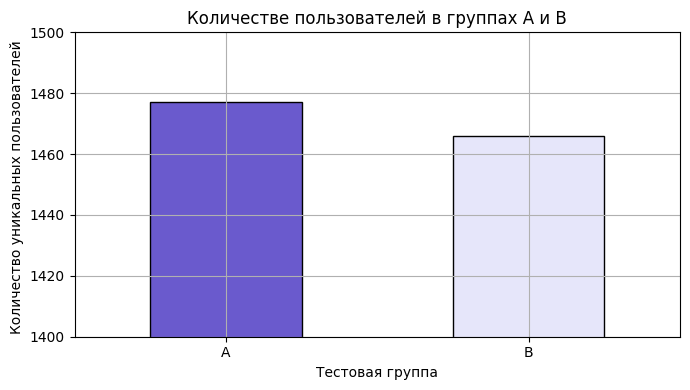

In [22]:
# Cоздаем фигуру и оси с нужным размером
fig, ax = plt.subplots(figsize=(7, 4))

# создаем столбчатую диаграмму на основании количества уникальных значений столбца 'category'
test_group_count.plot(
    kind='bar',
    ax=ax,
    legend=False,
    rot=0,
    color=['slateblue', 'lavender'],
    edgecolor='black'
)

# Устанавливаем подписи для заголовка, осей x и y
ax.set_title('Количестве пользователей в группах A и B')
ax.set_xlabel('Тестовая группа')
ax.set_ylabel('Количество уникальных пользователей ')
ax.grid(True)
plt.ylim(1400, 1500) 

plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей

Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B, или убедимся, что таких нет.

In [23]:
# Получаем множества уникальных пользователей для каждой группы
users_a = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].unique())
users_b = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].unique())

# Находим пересечение
intersection = users_a & users_b

# Выводим результат
print(f'Количество пользователей, которые встречаются одновременно в группах A и B: {len(intersection)}')

if len(intersection) == 0:
    print('Пересечений пользователей нет - группы независимы')
else:
    print('Обнаружены пользователи, попавшие в обе группы')

Количество пользователей, которые встречаются одновременно в группах A и B: 0
Пересечений пользователей нет - группы независимы


#### 3.3. Равномерность разделения пользователей по устройствам

Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным - типам устройств и регионам.

Построим две диаграммы:
- доля каждого типа устройства для пользователей из группы A,
- доля каждого типа устройства для пользователей из группы B.

Постараемся добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.

In [24]:
# Выделяем уникальных пользователей с их группой и устройством
users_device_unique = sessions_test_part.groupby('user_id').agg({
    'test_group': 'first',
    'device': 'first'
}).reset_index()

# Считаем распределение устройств для группы A
device_a = users_device_unique[users_device_unique['test_group'] == 'A']['device'].value_counts(normalize=True) * 100

# Считаем распределение устройств для группы B
device_b = users_device_unique[users_device_unique['test_group'] == 'B']['device'].value_counts(normalize=True) * 100

# Выводим результат
print(f'Распределение устройств в группе A:')
print(device_a)
print('-------')
print(f'Распределение устройств в группе B:')
print(device_b)

Распределение устройств в группе A:
device
Android    44.414353
PC         24.983074
iPhone     20.040623
Mac        10.561950
Name: proportion, dtype: float64
-------
Распределение устройств в группе B:
device
Android    45.566166
PC         25.989086
iPhone     18.349250
Mac        10.095498
Name: proportion, dtype: float64


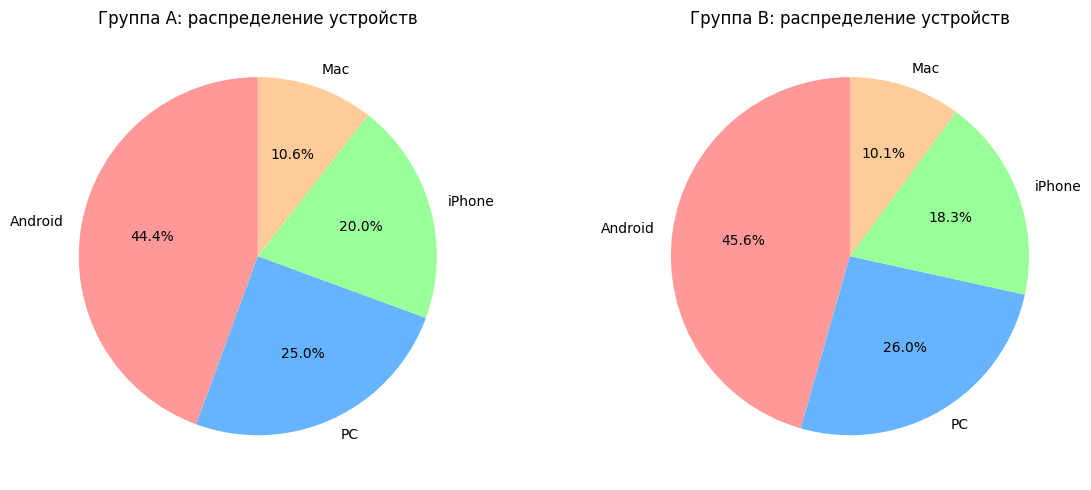

In [25]:
# Cоздаем фигуру и оси с нужным размером
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Круговая диаграмма для группы A
ax1.pie(
    device_a.values,
    labels=device_a.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
ax1.set_title('Группа A: распределение устройств')

# Круговая диаграмма для группы B
ax2.pie(
    device_b.values,
    labels=device_b.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
ax2.set_title('Группа B: распределение устройств')

# Выравниваем и показываем
plt.tight_layout()
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам

Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:
- доля каждого региона для пользователей из группы A,
- доля каждого региона для пользователей из группы B.

Добавим на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B.

In [26]:
# Выделяем уникальных пользователей с их группой и регионом
users_region_unique = sessions_test_part.groupby('user_id').agg({
    'test_group': 'first',
    'region': 'first'
}).reset_index()

# Считаем распределение регионов для группы A 
region_a = users_region_unique[users_region_unique['test_group'] == 'A']['region'].value_counts(normalize=True) * 100

# Считаем распределение регионов для группы A 
region_b = users_region_unique[users_region_unique['test_group'] == 'B']['region'].value_counts(normalize=True) * 100

# Выводим результат
print(f'Распределение устройств в группе A:')
print(region_a)
print('-------')
print(f'Распределение устройств в группе B:')
print(region_b)

Распределение устройств в группе A:
region
CIS     43.601896
MENA    41.232227
EU      15.165877
Name: proportion, dtype: float64
-------
Распределение устройств в группе B:
region
CIS     43.997271
MENA    41.200546
EU      14.802183
Name: proportion, dtype: float64


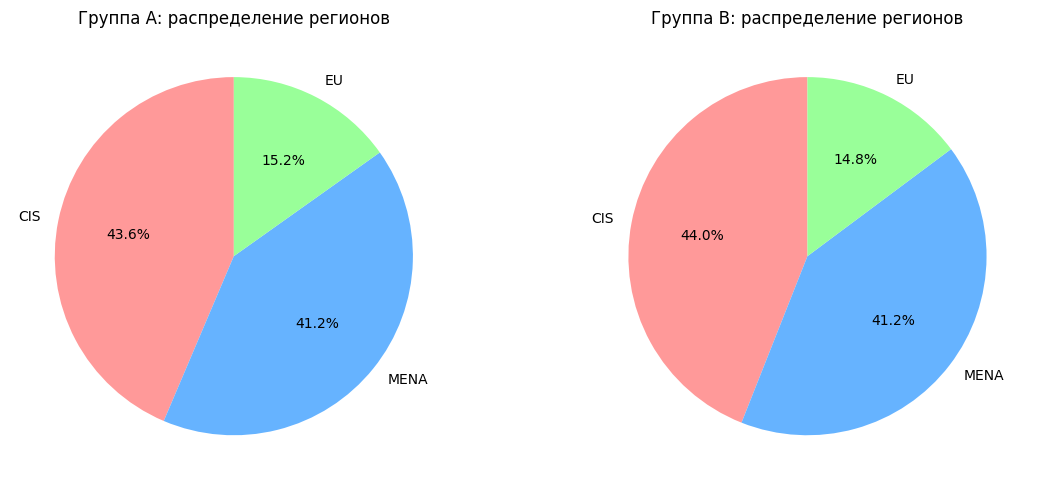

In [27]:
# Cоздаем фигуру и оси с нужным размером
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Круговая диаграмма для группы A
ax1.pie(
    region_a.values,
    labels=region_a.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
ax1.set_title('Группа A: распределение регионов')

# Круговая диаграмма для группы B
ax2.pie(
    region_b.values,
    labels=region_b.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99']
)
ax2.set_title('Группа B: распределение регионов')

# Выравниваем и показываем
plt.tight_layout()
plt.show()

#### 3.5. Вывод после проверки A/B-теста

**Выводы по результатам проверки A/B-теста:**
- **Количество пользователей в группах.** В первый день эксперимента (14 октября 2025 года) в группе A зафиксировано 1477 уникальных пользователей, в группе B - 1466. Относительная разница составила 0,74% в пользу группы A. Группы можно считать сбалансированными по  количеству пользователей.
- **Независимость выборок.** Проверка пересечения пользователей показала, что ни один пользователь не встречается одновременно в обеих группах. Это означает, что  выборки полностью независимы.
- **Распределение по типам устройств.** Доли пользователей с разными устройствами в группах A и B практически идентичны и поэтому не нарушают сопоставимости групп по данному признаку:
    - Android: 44,4% (A) vs 45,6% (B)
    - PC: 25,0% (A) vs 26,0% (B)
    - iPhone: 20,0% (A) vs 18,3% (B)
    - Mac: 10,6% (A) vs 10,1% (B)
- **Распределение по регионам.** Распределение пользователей также хорошо сбалансировано по регионам:
    - CIS: 43,6% (A) vs 44,0% (B)
    - MENA: 41,2% (A) vs 41,2% (B)
    - EU: 15,2% (A) vs 14,8% (B)

**Вывод:** A/B-тест организован корректно: количество пользователей в группах практически идентично (разница 0,74%), также сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам. Нарушения, которые могли бы исказить результаты теста, не обнаружены.

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

In [28]:
# Загружаем данные в переменную sessions_test
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

# Выводим первые строки полученного датасета
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [29]:
# Создаём столбец good_session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

# Проверяем результат
sessions_test.sample(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
89673,DA4FA86CF7024657,457901B0733C5EA2,2025-10-19,2025-10-19 20:53:29,2025-10-14,3,0,4,CIS,Android,B,1
67638,EC53DD76BB16E5C9,A0C89BA891699436,2025-10-20,2025-10-20 15:00:12,2025-10-16,3,0,3,CIS,PC,B,0
35547,3814B4413BB03E91,87F86A95FF6DADEE,2025-10-27,2025-10-27 20:01:55,2025-10-17,3,0,6,CIS,Mac,B,1
14628,C9BA60AB9E2614C1,DEEC2BFF81B8382A,2025-10-15,2025-10-15 13:09:59,2025-10-14,2,0,3,CIS,Android,A,0
46928,4C971FC14A6E52C8,BA8D3378D4E7CDCC,2025-10-21,2025-10-21 19:44:18,2025-10-15,3,0,3,CIS,Android,A,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик

Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

**Нулевая гипотеза** в данном приложении будет говорить о том, что новый алгоритм не влияет на вовлечённость пользователей, то есть разница между группами A и B равна нулю.

**Альтернативная гипотеза** будет говорить о том, что новый алгоритм увеличивает вовличенность пользователей, т.е. доля сессий с 4 и более страницами в группе B выше, чем в группе A.

**Метрики для нового алгоритма рекомендательной системы приложения:**
- **Целевая метрика (главный показатель успеха эксперимента):**
    - В данному случае целевой метрикой будет являться доля сессий с просмотром 4 и более страниц (good_session = 1). Этот показатель должен отражать, насколько контент, предлагаемый новым алгоритмом, захватывает пользователя. Если алгоритм действительно лучше подбирает материалы, люди должны чаще задерживаться в приложении и листать дальше.
- **Прокси-метрики (показатели, которые должны улучшиться параллельно с основной метрикой):**
    - Среднее количество просмотренных страниц за сессию, т.е. если людям контнент стал интереснее, то они будут в среднем просматривать больше страниц приложения.
    - Количество сессий на пользователя, т.е. если контент стал привлекательнее, люди могут начать чаще заходить.
    - Время, проведённое в приложении, т.е. увеличение данного времени будет свидетельствовать о росте вовлечённости пользователей.
- **Барьерные метрики (показатели, которые не должны ухудшиться, чтобы нововведение не навредило пользовательскому опыту):**
    - Доля пользователей, ушедших после первой сессии.
    - Средняя продолжительность сессии (если она резко сократится, это может указывать на разочарование).
    - Частота технических ошибок или сбоев (при изменении алгоритма).

#### 4.3. Сравнение доли успешных сессий

Перейдём к анализу ключевой метрики - доле успешных первых сессий.

Используя созданный на первом шаге задания столбец `good_session`, рассчитаем долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразим на экране.

In [30]:
# Оставляем только первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# Считаем общее количество сессий и количество успешных сессий к каждой из групп
stats_good_sessions = first_sessions.groupby('test_group').agg(
    total_sessions=('good_session', 'count'), 
    successful_sessions=('good_session', 'sum')
)

# Считаем долю успешных сессий для выборок
stats_good_sessions['share_good_sessions'] = (stats_good_sessions['successful_sessions'] / stats_good_sessions['total_sessions']) * 100

# Извлекаем значения для групп A и B
success_test_a = stats_good_sessions.loc['A', 'share_good_sessions']
success_test_b = stats_good_sessions.loc['B', 'share_good_sessions']

# Считем разницу в показателях выборок
diff = round(success_test_b - success_test_a, 2)

print('Общее количество сессий, количество успешных сессий к каждой из групп и доля успешных сессий для выборок')
print(stats_good_sessions)
print('--------------------------------------------------------------------------')
print(f'Доля успешных первых сессий в группе A: {success_test_a:.1f}%')
print(f'Доля успешных первых сессий в группе B: {success_test_b:.1f}%')
print(f'Разница (B - A): {diff:.2f}%')

Общее количество сессий, количество успешных сессий к каждой из групп и доля успешных сессий для выборок
            total_sessions  successful_sessions  share_good_sessions
test_group                                                          
A                    15162                 4787            31.572352
B                    15416                 4851            31.467307
--------------------------------------------------------------------------
Доля успешных первых сессий в группе A: 31.6%
Доля успешных первых сессий в группе B: 31.5%
Разница (B - A): -0.11%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем мы убедились, что количество успешных сессий в тестовой выборке примерно на 0.1% ниже, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

Выведем на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [31]:
# Оставляем только первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# Определяем размеры групп
n_a = first_sessions[first_sessions['test_group'] == 'A'].shape[0]
n_b = first_sessions[first_sessions['test_group'] == 'B'].shape[0]

# Количество успешных сессий (good_session = 1) в каждой группе
m_a = first_sessions[(first_sessions['test_group'] == 'A') & (first_sessions['good_session'] == 1)].shape[0]
m_b = first_sessions[(first_sessions['test_group'] == 'B') & (first_sessions['good_session'] == 1)].shape[0]

# Доли успешных сессий
p_a = m_a / n_a
p_b = m_b / n_b

# Уровень значимости
alpha = 0.05

# z-тест (альтернатива: доля в группе B больше, чем в A)
stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller'
)

print(f'Результаты z-теста:')
print(f'p-value = {p_value_ztest:.4f}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза не отвергается: наблюдаемое различие не является статистически значимым, т.е. нет оснований считать, что новый алгоритм увеличил долю успешных сессий.')
else:
    print('Нулевая гипотеза отвергается: новый алгоритм статистически значимо повысил долю успешных сессий.')

# Итоговая интерпретация
text_interpretation = 'увеличилась' if p_value_ztest <= alpha else 'не изменилась'
print(f'Доля успешных сессий в группе с новым алгоритмом {text_interpretation} по сравнению с контрольной группой.')

Результаты z-теста:
p-value = 0.5784
Нулевая гипотеза не отвергается: наблюдаемое различие не является статистически значимым, т.е. нет оснований считать, что новый алгоритм увеличил долю успешных сессий.
Доля успешных сессий в группе с новым алгоритмом не изменилась по сравнению с контрольной группой.


#### 4.5. Вывод по результатам A/B-эксперимента

**В ходе проведённого A/B-теста нового алгоритма рекомендаций были получены следующие результаты:**
- **Характеристики эксперимента:**
    - В тесте участвовали две группы: контрольная (A) и тестовая (B) с новым алгоритмом.
    - Общее количество сессий в группе A составило 15 162, в группе B - 15 416.
    - Длительность эксперимента охватывала период, за который были собраны данные, а именно: с 2025-10-14 по 2025-11-02
- **Влияние на ключевую метрику:**
    - Доля успешных сессий (с просмотром 4 и более страниц) в группе A составила 31,6%, в группе B - 31,5%.
    - Разница между группами оказалась крайне малой: -0,11 процентного пункта (т.е. в тестовой группе значение немного ниже).
- **Статистическая значимость:**
    - Полученное p‑value = 0,5784, что значительно превышает заданный уровень значимости α = 0,05.
    - Это означает, что наблюдаемое различие не является статистически значимым - мы не можем отвергнуть нулевую гипотезу об отсутствии эффекта.
- **Рекомендация по внедрению:**
    - Поскольку новый алгоритм не продемонстрировал статистически значимого улучшения ключевой метрики (более того, зафиксировано незначимое снижение), его внедрение в текущем виде нецелесообразно.